In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import dimod
import pandas as pd
from IPython.display import Image


In [2]:
num_vars = 4

In [3]:
with open(f'../exp/eBeyond/p{num_vars}.cnf.pkl', 'rb') as f:
    instance = pickle.load(f)

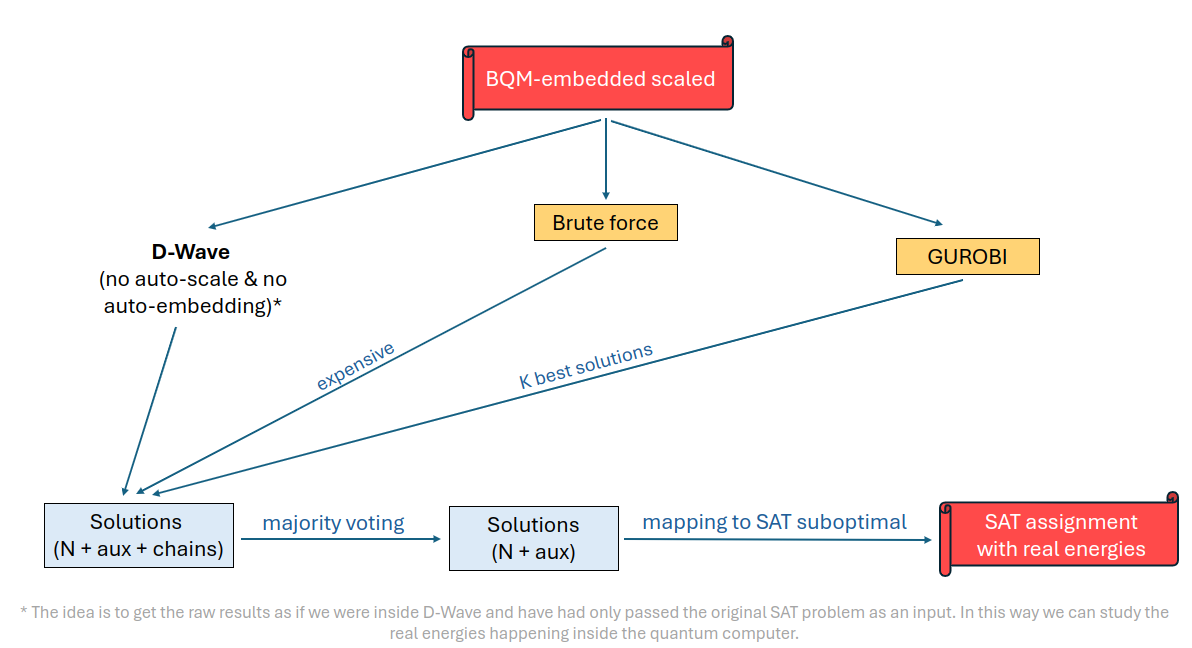

In [4]:
Image(filename='../figs/Final_assignments_n_real_energies.png') 

## D-Wave results

In [5]:
def count_unsatisfied_clauses(assignment, clauses):
    count = 0
    for c in clauses:
        for l in c:
            if (l > 0 and assignment[np.abs(l)-1] == 1) or (l < 0 and assignment[np.abs(l)-1] == -1):
                count += 1
                break
    return str(len(clauses)-count)

In [6]:
def unchain_dwave_solutions(sample_set, embedding):
    majority_voting_dict = {}
    for key, value in embedding.items():
        chain_length = len(value)
        chain_df = dimod.keep_variables(sample_set, value).to_pandas_dataframe().iloc[:,0:chain_length]
        majority_voting_dict[key] = chain_df.mode(axis=1)[0]
            
    solutions_bqm_embedded_df = pd.DataFrame(majority_voting_dict)
    solutions_bqm_embedded_df['Real Energy'] = sample_set.to_pandas_dataframe()['energy']
    solutions_bqm_embedded_df['Occurrences'] = sample_set.to_pandas_dataframe()['num_occurrences']
    return solutions_bqm_embedded_df

In [7]:
def groupby_subopt(sample_set, embedding, SAT_num_vars):
    solutions_bqm_embedded_df_aux = unchain_dwave_solutions(sample_set, embedding)
    solutions_bqm_embedded_df = solutions_bqm_embedded_df_aux.loc[solutions_bqm_embedded_df_aux.index.repeat(solutions_bqm_embedded_df_aux.Occurrences)].reset_index(drop=True).drop(columns=['Occurrences'])
    assigment_df = solutions_bqm_embedded_df[np.arange(0,SAT_num_vars)]
    num_unsatisfied_clauses = []
    for _, row in assigment_df.iterrows():
        assigment = dict(row)
        o = count_unsatisfied_clauses(assigment, instance.clauses)
        num_unsatisfied_clauses.append(o)
    solutions_bqm_embedded_df['o'] = num_unsatisfied_clauses
    grouped_dfs = solutions_bqm_embedded_df.groupby('o')
    return grouped_dfs

In [8]:
gadgets = [
    "Nuesslein1",
    "Nuesslein2",
    "CJ1",
    "CJ2"
]

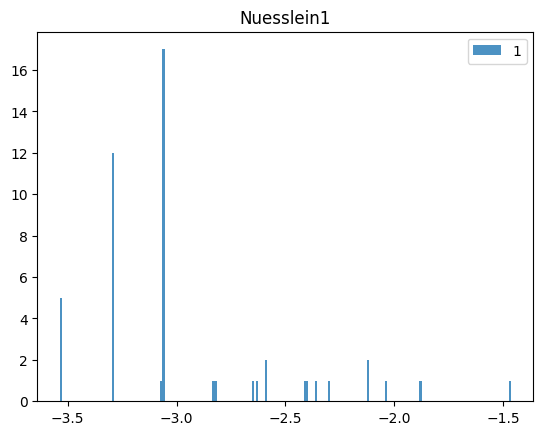

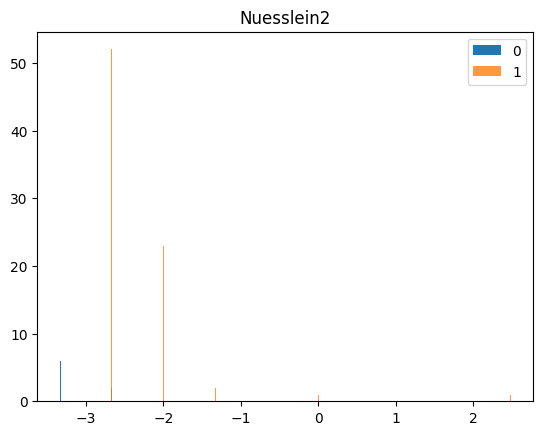

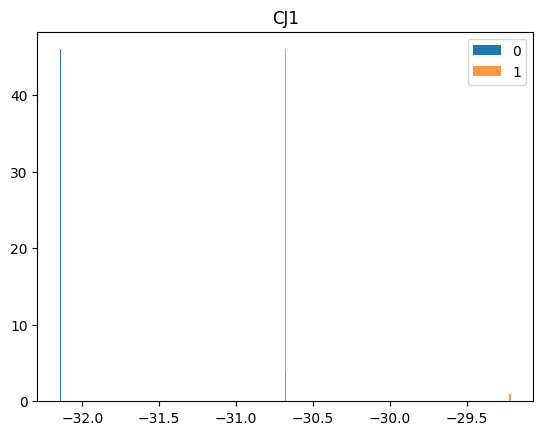

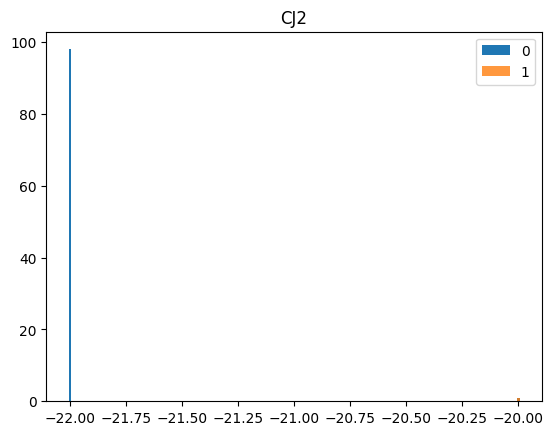

In [9]:
for gadget in gadgets:
    grouped_dfs = groupby_subopt(sample_set=getattr(instance, gadget).response_dwave_from_scaled_bqm_embedded, embedding=getattr(instance, gadget).bqm_embedded['embedding'], SAT_num_vars=num_vars)
    for group_key, sub_opt_df in grouped_dfs:
        if group_key in ['0', '1']:
            plt.bar(np.unique(np.round(sub_opt_df['Real Energy'].values, 2), return_counts=True)[0],
                    np.unique(np.round(sub_opt_df['Real Energy'].values, 2), return_counts=True)[1], width=0.01,
                    alpha=1 - 0.2 * int(group_key), label=group_key)
            plt.legend()
    plt.title(f"{gadget}")
    plt.show()

## GUROBI results

In [10]:
from gurobipy import Model, LinExpr, GRB, sys

In [11]:
def solve_gurobi(scaled_bqm_embedded, num_solutions=100):
    qubits = list(scaled_bqm_embedded.variables)
    q_names = list(map(str,scaled_bqm_embedded.variables))

    model = Model(name = 'linear program')
    q=model.addVars(qubits, name=q_names, vtype = GRB.INTEGER, lb=-1, ub=1)
   
    for qub in qubits:
        model.addConstr(q[qub]*q[qub] == 1, name='non_zero')

    obj_fn = LinExpr()
    for (u, v), bias in scaled_bqm_embedded.quadratic.items():
        obj_fn += bias * q[u] * q[v]
    for v, bias in scaled_bqm_embedded.linear.items():
        obj_fn += bias * q[v]
    model.setObjective(obj_fn, GRB.MINIMIZE)

    solutions = []
    model.setParam(GRB.Param.PoolSolutions, num_solutions)
    model.setParam(GRB.Param.PoolSearchMode, 2)
    #model.setParam(GRB.Param.PoolGap, 100)
    model.setParam(GRB.Param.Cutoff, GRB.INFINITY)
    model.optimize()
   
    nSolutions = model.SolCount
    # print(f"Number of solutions found: {nSolutions}")
   
    for e in range(nSolutions):
        model.setParam(GRB.Param.SolutionNumber, e)
   
        # Status checking
        status = model.Status
        if status in (GRB.INF_OR_UNBD, GRB.INFEASIBLE, GRB.UNBOUNDED):
            print("The model cannot be solved because it is infeasible or unbounded")
            sys.exit(1)
        if status != GRB.OPTIMAL:
            print(f"Optimization was stopped with status {status}")
            sys.exit(1)
   
        energy = model.PoolObjVal
   
        assignment = {}
        for v in model.getVars():
            if round(v.Xn)==1:
                assignment[int(v.varName)] = 1
            else:
                assignment[int(v.varName)] = -1
   
        solutions.append([list(assignment.values()), energy])

    return solutions

In [12]:
solutions = solve_gurobi(instance.Nuesslein2.scaled_bqm_embedded['scaled_bqm_embedded'], num_solutions=100)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-02
Set parameter PoolSolutions to value 100
Set parameter PoolSearchMode to value 2
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (linux64 - "Ubuntu 23.10")

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 0 rows, 29 columns and 0 nonzeros
Model fingerprint: 0xfe5b56b0
Model has 72 quadratic objective terms
Model has 29 quadratic constraints
Variable types: 0 continuous, 29 integer (0 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [8e-02, 4e-01]
  QObjective range [1e-01, 2e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
  QRHS range       [1e+00, 1e+00]
Found heuristic solution: objective -14.7240688
Presolve time: 0.00s
Presolved: 72 rows, 101 columns, 216 nonzeros
Fo

In [13]:
print(len(solutions[0][0]))

29


In [14]:
sample_set = instance.Nuesslein2.response_dwave_from_scaled_bqm_embedded
print(len(sample_set.to_pandas_dataframe().axes[1]))
print(sample_set.to_pandas_dataframe().axes[1])

32
Index([                   691,                    692,                    706,
                          707,                    722,                    737,
                          752,                    767,                    796,
                          797,                    826,                    827,
                          842,                    857,                   3213,
                         3228,                   3273,                   3288,
                         3303,                   3304,                   3318,
                         3319,                   3333,                   3348,
                         3363,                   3378,                   3393,
                         3408,                   3438, 'chain_break_fraction',
                     'energy',      'num_occurrences'],
      dtype='object')
